# 2. Feature Engineering

Extract KPIs, embeddings, and process statistics.

## 2.0 Install Dependencies

In [1]:
# Install required packages (safe to re-run; --quiet suppresses noise)
import subprocess, sys
subprocess.check_call([sys.executable, '-m', 'pip', 'install', '--quiet',
    'pandas',
    'pyarrow',
    'numpy',
    'scikit-learn',
    'joblib',
    'matplotlib',
    'seaborn',
    'sentence-transformers',
])


[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


0

## 2.1 Setup

In [2]:
import sys; from pathlib import Path
_here = Path.cwd()
for _p in [_here, *_here.parents]:
    if (_p / 'src' / 'data_ingestion.py').exists():
        _repo_root = _p
        _src = str(_p / 'src')
        if _src not in sys.path: sys.path.insert(0, _src)
        break
DATASET = "BPIC2012"
OUTPUT_DIR = _repo_root / 'output' / DATASET
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

## 2.1 Load Data

In [3]:
import pandas as pd
df = pd.read_parquet(OUTPUT_DIR / f'events_{DATASET}_train.parquet')
print(f"Loaded {len(df)} events")

Loaded 262200 events


## 2.2 Compute KPIs

In [4]:
from feature_engineering import compute_case_kpis
kpis = compute_case_kpis(df)
kpis.to_parquet(OUTPUT_DIR / f'kpis_{DATASET}_train.parquet', engine='pyarrow', index=False)
print('KPIs saved')

KPIs saved


## 2.3 Transition Matrix

In [5]:
from feature_engineering import compute_transition_matrix
trans_mat = compute_transition_matrix(df)
trans_mat.to_parquet(OUTPUT_DIR / f'transition_matrix_{DATASET}_train.parquet', engine='pyarrow')
print('Transition matrix saved')

Transition matrix saved


## 2.4 Activity Embeddings

In [6]:
from feature_engineering import ActivityEmbedder
import joblib, math

# Scale embed_dim with dataset size so the embedding space is large enough
# to represent all activities. Formula: next power-of-2 >= sqrt(n_acts)*4,
# clamped to [32, 128]. Matches the formula used in notebook 04.
_n_acts = df['activity'].nunique()
_embed_dim = int(min(128, max(32, 2 ** math.ceil(math.log2(max(32, int(math.sqrt(_n_acts) * 4)))))))
print(f'Activities: {_n_acts}  →  embed_dim: {_embed_dim}')

embedder = ActivityEmbedder(vector_size=_embed_dim, seed=42)
embedder.fit(df)
joblib.dump(embedder, OUTPUT_DIR / f'activity_embeddings.model')
print('Embeddings saved')

Activities: 24  →  embed_dim: 32


Embeddings saved


## 2.5 Terminal Classification

Classifies which activities represent bad terminal states (rejection, cancellation)
using semantic sentence embeddings (`all-MiniLM-L6-v2`). Runs once here and
saves the result so `ProcessEnv` can load it instantly without re-downloading
the model on every instantiation.

In [7]:
from feature_engineering import (
    classify_terminals, terminal_diagnostics, load_terminal_overrides,
)
import json

activities = sorted(df['activity'].unique().tolist())

# An activity counts as the end of a case only if, whenever it occurs, it
# occurs near the end (75% of its occurrences in the last 20% of the trace).
# The good/bad split then comes from the activity name.
#
# The previous rule kept anything that ended >=5% of traces, excluded the W_
# work-queue prefix, and silently fell back to keyword matching when that left
# nothing — which it always did on BPIC2012 and BPIC2017. That fallback
# produced "good terminals" ending zero real cases (A_PREACCEPTED sits 17% of
# the way through a trace). classify_terminals raises instead of falling back.
#
# Datasets whose activity names defeat the name classifier carry a committed
# hand-labelled file under config/terminal_labels/. BPIC2015 has one; the
# loan datasets do not need one.
overrides = load_terminal_overrides(DATASET)
if overrides:
    print(f'Applying {len(overrides)} manual labels from '
          f'config/terminal_labels/{DATASET}.json')

terminals = classify_terminals(df, overrides=overrides)
bad_terminals  = terminals['bad_terminals']
good_terminals = terminals['good_terminals']

if terminals['unknown_overrides']:
    print(f'WARNING: these override names are not outcome markers and were '
          f'ignored (typo?): {terminals["unknown_overrides"]}')

# Real-log cycle time: first to last event, per case, in days.
_ct = df.sort_values(['case_id', 'timestamp'], kind='stable').groupby('case_id')['timestamp']
_ct_days = ((_ct.max() - _ct.min()).dt.total_seconds() / 86400.0)
_real_cycle_days_median = float(_ct_days.median())
_real_cycle_days_mean = float(_ct_days.mean())

terminal_info = {
    'activities':           activities,
    'bad_terminals':        sorted(bad_terminals),
    'good_terminals':       sorted(good_terminals),
    'excluded_markers':     terminals['excluded_markers'],
    # Earliest step at which the environment may honour an outcome, taken from
    # the real log. Without it, a first-order Markov simulator composes real
    # edges into paths no case ever took: on BPIC2015 the shortest simulated
    # route to 'permit irrevocable' is 2 steps against a real minimum of 11,
    # and the trained agent took it in 100% of episodes.
    'min_steps_to_outcome': terminals['min_steps_to_outcome'],
    'steps_to_outcome':     terminals['steps_to_outcome'],
    # Base rates for the environment-decided verdict. The agent routes only
    # among non-terminal activities; the environment draws whether the case
    # succeeds from these rates, once per episode. Letting the agent route to
    # 'approved' made it reach a good outcome 94.8% of the time on BPIC2012
    # against a real rate of 17.7%.
    'outcome_base_rates':   terminals['outcome_base_rates'],
    # Real-log cycle time, so every chart that plots simulated cycle time has
    # a reference line to sit against. Without this the comparison figure
    # renders the bars with nothing to compare them to.
    'real_cycle_days_median': _real_cycle_days_median,
    'real_cycle_days_mean':   _real_cycle_days_mean,
    'thresholds':           terminals['thresholds'],
    'diagnostics':          terminals['diagnostics'],
}
with open(OUTPUT_DIR / 'terminal_classification.json', 'w') as f:
    json.dump(terminal_info, f, indent=2)

print(f'Good terminals: {sorted(good_terminals)}')
print(f'Bad terminals:  {sorted(bad_terminals)}')
if terminals['excluded_markers']:
    print(f'Excluded (near the end but outcome-neutral): '
          f'{len(terminals["excluded_markers"])} activities')

# Evidence table — position within the trace is what qualifies each one.
diag = terminal_diagnostics(df)
shown = diag.loc[sorted(set(good_terminals) | set(bad_terminals))]
shown = shown.assign(label=['bad' if a in bad_terminals else 'good' for a in shown.index])
print()
print(shown.sort_values('case_coverage', ascending=False).round(3).to_string())

# Real-log reference: what actually happens to cases in this log. These are the
# numbers any policy should be compared against, and the report currently has
# none of them.
_d = df.sort_values(['case_id', 'timestamp'], kind='stable')
_d = _d.assign(step=_d.groupby('case_id').cumcount() + 1)
_terms = set(good_terminals) | set(bad_terminals)
_hit = _d[_d['activity'].isin(_terms)].groupby('case_id').first()
_n = _d['case_id'].nunique()
if len(_hit):
    _good_rate = _hit['activity'].isin(good_terminals).mean()
    print()
    print(f'Real-log reference: {len(_hit) / _n:.1%} of cases reach a settled outcome; '
          f'of those {_good_rate:.1%} positive, {1 - _good_rate:.1%} negative.')
    print(f'Median steps to that outcome: {_hit["step"].median():.0f} '
          f'(median trace length {_d.groupby("case_id").size().median():.0f})')
    print(f'Median case cycle time: {_real_cycle_days_median:.2f} days '
          f'(mean {_real_cycle_days_mean:.2f})')

_sto = terminals['steps_to_outcome']
print()
print(f'Outcome floor: an episode may not reach an outcome before step '
      f'{terminals["min_steps_to_outcome"]} '
      f'(p{terminals["thresholds"]["outcome_floor_percentile"]} of the real distribution).')
print('  real steps-to-outcome: ' +
      '  '.join(f'{k}={v:.0f}' for k, v in _sto.items() if k.startswith('p')))

_obr = terminals['outcome_base_rates']
print()
print(f'Verdict base rate (drawn by the environment, not chosen by the agent): '
      f'{_obr["p_good"]:.1%} of concluding cases succeed.')

print()
print(f'Saved to {OUTPUT_DIR / "terminal_classification.json"}')

/mnt/hdd/Code/Python/.venv/lib64/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading weights:   0%|                                                                                              | 0/103 [00:00<?, ?it/s]

Loading weights: 100%|██████████████████████████████████████████████████████████████████████████████████| 103/103 [00:00<00:00, 8042.39it/s]

Good terminals: ['A_ACTIVATED', 'A_APPROVED', 'A_REGISTERED', 'O_ACCEPTED']
Bad terminals:  ['A_CANCELLED', 'A_DECLINED', 'O_DECLINED']



              occurrences  case_coverage  rel_pos_mean  rel_pos_p25  end_frac label
activity                                                                           
A_DECLINED           7635          0.583         0.935        0.857     0.262   bad
A_CANCELLED          2807          0.214         0.951        0.923     0.050   bad
A_ACTIVATED          2246          0.172         0.950        0.933     0.000  good
A_APPROVED           2246          0.172         0.930        0.909     0.000  good
A_REGISTERED         2246          0.172         0.943        0.923     0.000  good
O_ACCEPTED           2243          0.171         0.916        0.889     0.000  good
O_DECLINED            802          0.061         0.954        0.939     0.000   bad

Real-log reference: 97.0% of cases reach a settled outcome; of those 17.7% positive, 82.3% negative.
Median steps to that outcome: 9 (median trace length 11)
Median case cycle time: 0.81 days (mean 8.62)

Outcome floor: an episode may not rea

## 2.5 Visualization

Good terminals: ['A_ACTIVATED', 'A_APPROVED', 'A_REGISTERED', 'O_ACCEPTED']
Bad terminals:  ['A_CANCELLED', 'A_DECLINED', 'O_DECLINED']
Saved to /mnt/hdd/Code/Git/bwa/output/BPIC2012/feature_engineering_overview.png


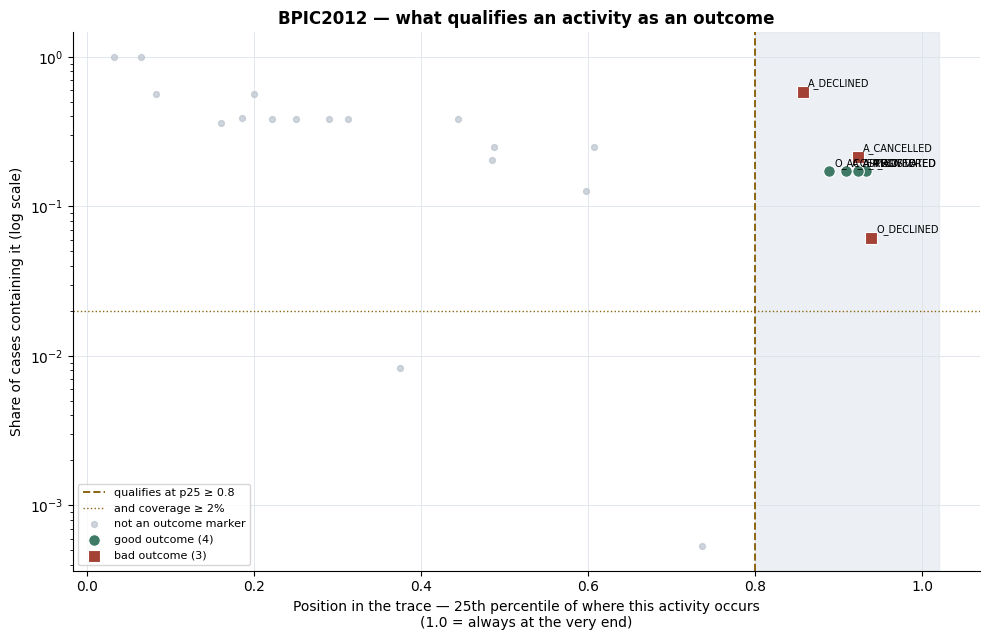

In [8]:
import figures, json
from feature_engineering import terminal_diagnostics

_tc = json.load(open(OUTPUT_DIR / 'terminal_classification.json'))

# Replaces the old four-panel overview. Its trace-ending-rate panel coloured
# the top-15 trace-enders green/red by good/bad, but the outcome markers that
# classify_terminals selects end roughly 0% of traces — they occur *near* the
# end, they do not end a case. So almost every bar rendered grey and the figure
# contradicted the labelling it was supposed to illustrate.
#
# This plots the two quantities that actually decide each label: how late in a
# trace the activity occurs, and how many cases contain it.
_diag = terminal_diagnostics(df)
figures.terminal_evidence(
    _diag,
    good=set(_tc['good_terminals']),
    bad=set(_tc['bad_terminals']),
    excluded=set(_tc.get('excluded_markers', [])),
    thresholds=_tc['thresholds'],
    out_path=OUTPUT_DIR / 'feature_engineering_overview.png',
    dataset=DATASET,
)
print(f"Good terminals: {sorted(_tc['good_terminals'])}")
print(f"Bad terminals:  {sorted(_tc['bad_terminals'])}")
print(f"Saved to {OUTPUT_DIR / 'feature_engineering_overview.png'}")
